In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
df = pd.read_csv("alz-speech.csv")

X = df[["sex", "age", "transcript"]]
y = df["ad"]

text_features = "transcript"
categorical_features = ["sex"]
numeric_features = ["age"]

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        ), text_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)

logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        C=1.0,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall"
}

results = cross_validate(
    logreg_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression Results")
for metric in scoring.keys():
    scores = results[f"test_{metric}"]
    print(f"{metric:10s}: {scores.mean():.4f} +- {scores.std():.4f}")


Logistic Regression Results
accuracy  : 0.7710 +- 0.0802
f1        : 0.7435 +- 0.1026
roc_auc   : 0.8639 +- 0.0657
precision : 0.8340 +- 0.1057
recall    : 0.6830 +- 0.1300


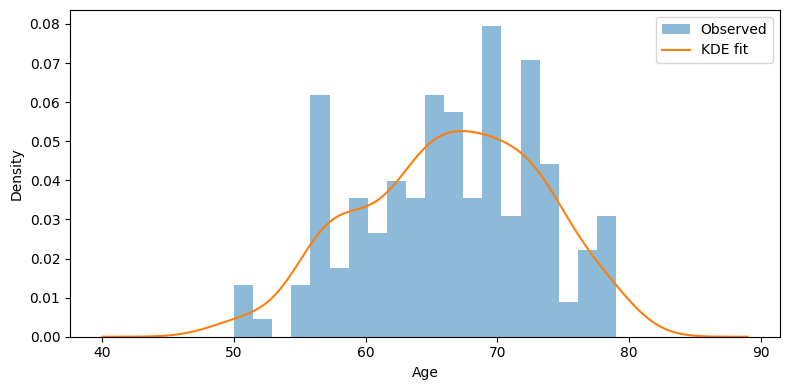

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

ages = df["age"].dropna().values

kde = gaussian_kde(ages, bw_method="scott")

n_samples = len(df)
synthetic_ages = kde.resample(n_samples).flatten()

# If ages should be integers or clipped to a plausible range
synthetic_ages = np.clip(np.round(synthetic_ages), ages.min(), ages.max()).astype(int)
x_grid = np.linspace(ages.min() - 10, ages.max() + 10, 500)

plt.figure(figsize=(8, 4))
plt.hist(ages, bins=20, density=True, alpha=0.5, label="Observed")
plt.plot(x_grid, kde(x_grid), label="KDE fit")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

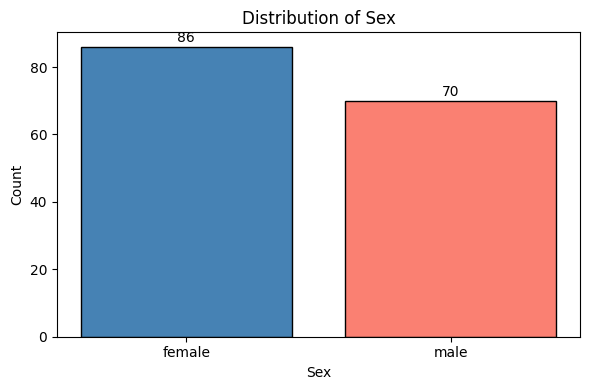

In [3]:
import matplotlib.pyplot as plt

sex_counts = df["sex"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(sex_counts.index, sex_counts.values, color=["steelblue", "salmon"], edgecolor="black")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Distribution of Sex")
for i, (label, count) in enumerate(sex_counts.items()):
    plt.text(i, count + 0.5, str(count), ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

df = pd.read_csv("alz-speech.csv")

X = df[["sex", "age", "transcript"]]
y = df["ad"]

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        ), "transcript"),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), ["sex"]),
    ]
)
svm_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall"
}

results = cross_validate(
    svm_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Linear SVM Results")
for metric in scoring.keys():
    scores = results[f"test_{metric}"]
    print(f"{metric:10s}: {scores.mean():.4f} +- {scores.std():.4f}")

Linear SVM Results
accuracy  : 0.8010 +- 0.0686
f1        : 0.7726 +- 0.0931
roc_auc   : 0.8766 +- 0.0580
precision : 0.8818 +- 0.0851
recall    : 0.6996 +- 0.1265


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        ), "transcript"),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), ["sex"]),
    ]
)

rf_pipeline = Pipeline([
    ("preprocess", rf_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall"
}

results = cross_validate(rf_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print("Random Forest Results")
for metric in scoring.keys():
    scores = results[f"test_{metric}"]
    print(f"{metric:10s}: {scores.mean():.4f} +- {scores.std():.4f}")


Random Forest Results
accuracy  : 0.8192 +- 0.0650
f1        : 0.8144 +- 0.0674
roc_auc   : 0.9054 +- 0.0521
precision : 0.8405 +- 0.0885
recall    : 0.7974 +- 0.0894


In [ ]:
from sklearn.model_selection import train_test_split

models = {
    "LogReg": build_pipeline(LogisticRegression(C=1.0, solver="liblinear", max_iter=5000, random_state=42)),
    "SVM":    build_pipeline(SVC(kernel="linear", C=1.0, probability=True, random_state=42)),
    "RF":     build_pipeline(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
}

X_all = real_df[FEATURES]
y_all = real_df[TARGET]

# Collect scores across 20 random splits
scores = {name: {m: [] for m in METRICS} for name in models}

for seed in range(20):
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=seed
    )
    for name, pipeline in models.items():
        result = evaluate(pipeline, X_train, y_train, X_test, y_test)
        for metric, value in result.items():
            scores[name][metric].append(value)

# Print results
print("80/20 Holdout  —  mean ± std over 20 random splits\n")
print(f"{'Metric':<12}", end="")
for name in models:
    print(f"{name:>20}", end="")
print()
print("-" * (12 + 20 * len(models)))
for metric in METRICS:
    print(f"{metric:<12}", end="")
    for name in models:
        mean = np.mean(scores[name][metric])
        std  = np.std(scores[name][metric])
        print(f"    {mean:.4f} ± {std:.4f}", end="")
    print()

# Paraphrase Augmentation Experiments
#
# Test set  → original real transcripts of held-out subjects
# Train set → varies by config (see CONFIGS below)
#
# Key rule: paraphrases of test subjects are never in training.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

real_df = pd.read_csv("alz-speech.csv")
para_df = pd.read_csv("alz-speech-paraphrased.csv")

FEATURES = ["sex", "age", "transcript"]
TARGET   = "ad"
METRICS  = ["accuracy", "f1", "roc_auc", "precision", "recall"]

print(f"Real data:        {len(real_df)} transcripts ({real_df['subject'].nunique()} subjects)")
print(f"Paraphrased data: {len(para_df)} transcripts")

# ------------------------------------------------------------------
# Shared helpers used by both the holdout benchmarks and the
# paraphrase experiments below.
# ------------------------------------------------------------------

def build_preprocessor():
    """TF-IDF on transcript + one-hot on sex."""
    return ColumnTransformer(transformers=[
        ("text", TfidfVectorizer(
            lowercase=True, stop_words="english",
            ngram_range=(1, 2), min_df=2, max_df=0.95
        ), "transcript"),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), ["sex"]),
    ])

def build_pipeline(model):
    """Wrap a sklearn model with the shared preprocessor."""
    return Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", model),
    ])

def evaluate(pipeline, X_train, y_train, X_test, y_test):
    """Fit pipeline and return a dict of classification metrics."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, y_prob),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
    }

In [ ]:
# What training data each config uses
CONFIGS = {
    "Real Only":         {"use_real": True,  "use_para": False},
    "Real + Paraphrase": {"use_real": True,  "use_para": True},
    "Paraphrase Only":   {"use_real": False, "use_para": True},
}

models = {
    "LogReg": build_pipeline(LogisticRegression(C=1.0, solver="liblinear", max_iter=5000, random_state=42)),
    "SVM":    build_pipeline(SVC(kernel="linear", C=1.0, probability=True, random_state=42)),
    "RF":     build_pipeline(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
}

# Separate subjects by label so we can do a stratified subject-level split
ad_subjects   = real_df[real_df["ad"] == 1]["subject"].unique().tolist()
ctrl_subjects = real_df[real_df["ad"] == 0]["subject"].unique().tolist()

n_test_ad   = max(1, int(len(ad_subjects)   * 0.20))
n_test_ctrl = max(1, int(len(ctrl_subjects) * 0.20))

# scores[config][model][metric] = list of values, one per seed
scores = {
    cfg: {model: {m: [] for m in METRICS} for model in models}
    for cfg in CONFIGS
}

for seed in range(20):
    rng = np.random.default_rng(seed)

    # Pick held-out test subjects (stratified)
    test_subjects  = set(rng.choice(ad_subjects,   n_test_ad,   replace=False).tolist()
                       + rng.choice(ctrl_subjects, n_test_ctrl, replace=False).tolist())
    train_subjects = set(real_df["subject"].unique()) - test_subjects

    # Test set: only original transcripts of held-out subjects
    test_data = real_df[real_df["subject"].isin(test_subjects)]
    X_test = test_data[FEATURES]
    y_test = test_data[TARGET].astype(int)

    for cfg_name, cfg in CONFIGS.items():

        # Build training set from whichever sources this config uses
        train_parts = []
        if cfg["use_real"]:
            train_parts.append(real_df[real_df["subject"].isin(train_subjects)])
        if cfg["use_para"]:
            train_parts.append(para_df[para_df["subject"].isin(train_subjects)])

        train_data = pd.concat(train_parts, ignore_index=True)
        X_train = train_data[FEATURES]
        y_train = train_data[TARGET].astype(int)

        for model_name, pipeline in models.items():
            result = evaluate(pipeline, X_train, y_train, X_test, y_test)
            for metric, value in result.items():
                scores[cfg_name][model_name][metric].append(value)

print("Done. Run the next cell to see results.")

In [ ]:
for model_name in models:
    print(f"\n{model_name}")
    print("=" * 65)
    print(f"{'Metric':<12}", end="")
    for cfg_name in CONFIGS:
        print(f"{cfg_name:>22}", end="")
    print()
    print("-" * 65)
    for metric in METRICS:
        print(f"{metric:<12}", end="")
        for cfg_name in CONFIGS:
            vals = scores[cfg_name][model_name][metric]
            mean, std = np.mean(vals), np.std(vals)
            print(f"   {mean:.3f} ± {std:.3f}      ", end="")
        print()